# Natural Language Processing – Text Classification and Sentiment Analysis

## Improving Customer Satisfaction through Automated Review Sentiment Analysis

### Objective

The objective of this project is to build an automated Sentiment Analysis System
to classify Amazon customer reviews as Positive or Negative.

This analysis will help to:

- Monitor product performance
- Identify negative customer feedback
- Improve customer satisfaction
- Address complaints faster

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

pd.set_option("display.max_colwidth", 200)

sns.set_theme(style="whitegrid")

In [32]:
# Load the Amazon customer reviews dataset
file_path = "amazonreviews.tsv"

df = pd.read_csv(file_path, sep="\t")

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (10000, 2)


,label,review
0,pos,Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono...
1,pos,The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Ya...
2,pos,"Amazing!: This soundtrack is my favorite music of all time, hands down. The intense sadness of ""Prisoners of Fate"" (which means all the more if you've played the game) and the hope in ""A Distant P..."
3,pos,Excellent Soundtrack: I truly like this soundtrack and I enjoy video game music. I have played this game and most of the music on here I enjoy and it's truly relaxing and peaceful.On disk one. my ...
4,pos,"Remember, Pull Your Jaw Off The Floor After Hearing it: If you've played the game, you know how divine the music is! Every single song tells a story of the game, it's that good! The greatest songs..."


In [33]:
# Check dataset structure and data types
print("Dataset Information:")
print(df.info())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   10000 non-null  str  
 1   review  10000 non-null  str  
dtypes: str(2)
memory usage: 156.4 KB
None

Column Names:
['label', 'review']

Missing Values:
label     0
review    0
dtype: int64

Duplicate Rows:
0


In [34]:
# Check for missing values and duplicate rows

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
label     0
review    0
dtype: int64

Duplicate rows:
0


In [35]:
# Data Cleaning

# Remove rows with missing labels or reviews
df = df.dropna(subset=["label", "review"])

# Remove duplicate rows
df = df.drop_duplicates()

# Reset the index after cleaning
df = df.reset_index(drop=True)

print("Dataset shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(df.duplicated().sum())

Dataset shape after cleaning: (10000, 2)

Missing values after cleaning:
label     0
review    0
dtype: int64

Duplicate rows after cleaning:
0


In [36]:
# Text Preprocessing

# Get English stopwords from scikit-learn
stop_words = set(ENGLISH_STOP_WORDS)

# Function to clean and preprocess each review
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Keep only alphabetic characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Split text into words and remove stopwords
    words = [word for word in text.split() if word not in stop_words]

    # Join words back into a sentence
    return " ".join(words)

# Apply preprocessing to the review column
df["clean_review"] = df["review"].apply(preprocess_text)

# Display original and cleaned reviews
display(df[["review", "clean_review"]].head())

,review,clean_review
0,Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono...,stuning non gamer sound track beautiful paints senery mind recomend people hate vid game music played game chrono cross games played best music backs away crude keyboarding takes fresher step grat...
1,The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Ya...,best soundtrack m reading lot reviews saying best game soundtrack figured d write review disagree bit opinino yasunori mitsuda s ultimate masterpiece music timeless m listening years beauty simply...
2,"Amazing!: This soundtrack is my favorite music of all time, hands down. The intense sadness of ""Prisoners of Fate"" (which means all the more if you've played the game) and the hope in ""A Distant P...",amazing soundtrack favorite music time hands intense sadness prisoners fate means ve played game hope distant promise girl stole star important inspiration personally teen years higher energy trac...
3,Excellent Soundtrack: I truly like this soundtrack and I enjoy video game music. I have played this game and most of the music on here I enjoy and it's truly relaxing and peaceful.On disk one. my ...,excellent soundtrack truly like soundtrack enjoy video game music played game music enjoy s truly relaxing peaceful disk favorites scars time life death forest illusion fortress ancient dragons lo...
4,"Remember, Pull Your Jaw Off The Floor After Hearing it: If you've played the game, you know how divine the music is! Every single song tells a story of the game, it's that good! The greatest songs...",remember pull jaw floor hearing ve played game know divine music single song tells story game s good greatest songs doubt chrono cross time s scar magical dreamers wind stars sea radical dreamers ...


Sentiment Counts:
label
neg    5097
pos    4903
Name: count, dtype: int64


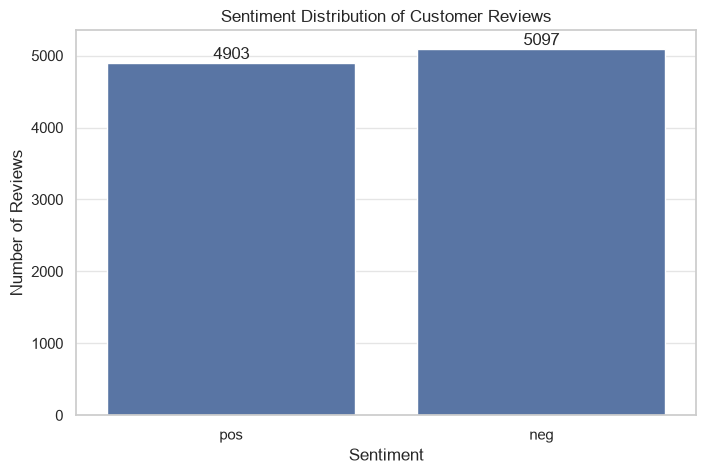

In [37]:
# Sentiment Distribution

# Count the number of positive and negative reviews
sentiment_counts = df["label"].value_counts()

print("Sentiment Counts:")
print(sentiment_counts)

# Visualize the sentiment distribution
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x="label")

plt.title("Sentiment Distribution of Customer Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

# Display values on top of the bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()


In [38]:
# Most Common Words in Positive and Negative Reviews

def get_common_words(text_series, n=20):
    words = " ".join(text_series).split()
    return Counter(words).most_common(n)

# Get positive and negative reviews
positive_reviews = df[df["label"] == "pos"]["clean_review"]
negative_reviews = df[df["label"] == "neg"]["clean_review"]

# Find the 20 most common words
positive_words = get_common_words(positive_reviews, 20)
negative_words = get_common_words(negative_reviews, 20)

print("Top 20 Words in Positive Reviews:")
display(pd.DataFrame(positive_words, columns=["Word", "Frequency"]))

print("\nTop 20 Words in Negative Reviews:")
display(pd.DataFrame(negative_words, columns=["Word", "Frequency"]))

Top 20 Words in Positive Reviews:


,Word,Frequency
0,book,3390
1,s,3179
2,great,2135
3,t,1871
4,good,1667
5,read,1605
6,like,1290
7,movie,1121
8,just,1036
9,time,924



Top 20 Words in Negative Reviews:


,Word,Frequency
0,t,3599
1,book,3277
2,s,2919
3,like,1569
4,just,1526
5,movie,1519
6,read,1222
7,good,1160
8,don,1135
9,time,1072


In [39]:
# Improved Text Preprocessing

stop_words = set(ENGLISH_STOP_WORDS)

def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Handle common contractions before removing punctuation
    text = re.sub(r"n't\b", " not", text)
    text = re.sub(r"'re\b", " are", text)
    text = re.sub(r"'ve\b", " have", text)
    text = re.sub(r"'ll\b", " will", text)
    text = re.sub(r"'d\b", " would", text)
    text = re.sub(r"'m\b", " am", text)
    text = re.sub(r"'s\b", " ", text)

    # Keep only alphabetic characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove stopwords and very short words
    words = [
        word for word in text.split()
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(words)

# Apply the improved preprocessing
df["clean_review"] = df["review"].apply(preprocess_text)

# Display original and cleaned reviews
display(df[["review", "clean_review"]].head())


,review,clean_review
0,Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono...,stuning non gamer sound track beautiful paints senery mind recomend people hate vid game music played game chrono cross games played best music backs away crude keyboarding takes fresher step grat...
1,The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Ya...,best soundtrack reading lot reviews saying best game soundtrack figured write review disagree bit opinino yasunori mitsuda ultimate masterpiece music timeless listening years beauty simply refuses...
2,"Amazing!: This soundtrack is my favorite music of all time, hands down. The intense sadness of ""Prisoners of Fate"" (which means all the more if you've played the game) and the hope in ""A Distant P...",amazing soundtrack favorite music time hands intense sadness prisoners fate means played game hope distant promise girl stole star important inspiration personally teen years higher energy tracks ...
3,Excellent Soundtrack: I truly like this soundtrack and I enjoy video game music. I have played this game and most of the music on here I enjoy and it's truly relaxing and peaceful.On disk one. my ...,excellent soundtrack truly like soundtrack enjoy video game music played game music enjoy truly relaxing peaceful disk favorites scars time life death forest illusion fortress ancient dragons lost...
4,"Remember, Pull Your Jaw Off The Floor After Hearing it: If you've played the game, you know how divine the music is! Every single song tells a story of the game, it's that good! The greatest songs...",remember pull jaw floor hearing played game know divine music single song tells story game good greatest songs doubt chrono cross time scar magical dreamers wind stars sea radical dreamers unstole...


# Most Common Words in Positive and Negative Reviews

In [40]:
# Most Common Words in Positive and Negative Reviews

def get_common_words(text_series, n=20):
    words = " ".join(text_series).split()
    return Counter(words).most_common(n)


# Select positive and negative reviews
positive_reviews = df[df["label"] == "pos"]["clean_review"]
negative_reviews = df[df["label"] == "neg"]["clean_review"]


# Get the 20 most common words
positive_words = get_common_words(positive_reviews, 20)
negative_words = get_common_words(negative_reviews, 20)


# Display positive words
print("Top 20 Words in Positive Reviews:")
display(pd.DataFrame(
    positive_words,
    columns=["Word", "Frequency"]
))


# Display negative words
print("\nTop 20 Words in Negative Reviews:")
display(pd.DataFrame(
    negative_words,
    columns=["Word", "Frequency"]
))

Top 20 Words in Positive Reviews:


,Word,Frequency
0,book,3390
1,great,2135
2,good,1667
3,read,1605
4,like,1290
5,movie,1121
6,just,1036
7,time,924
8,love,911
9,really,832



Top 20 Words in Negative Reviews:


,Word,Frequency
0,book,3277
1,like,1569
2,just,1526
3,movie,1519
4,did,1224
5,read,1222
6,good,1160
7,time,1072
8,does,934
9,buy,835


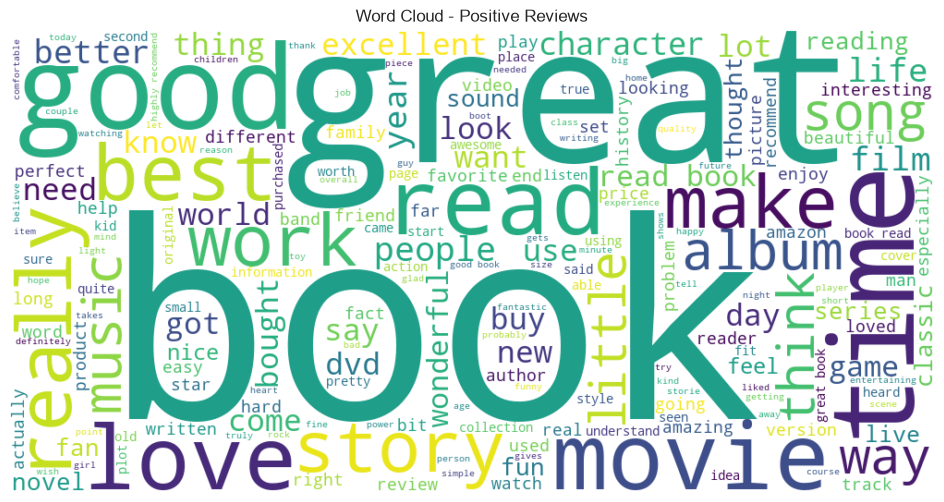

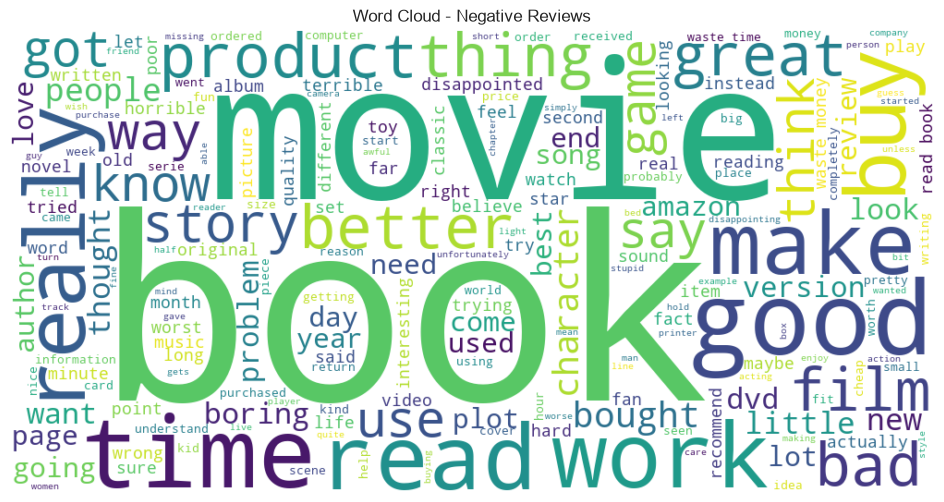

In [41]:
# Word Clouds for Positive and Negative Reviews

# Combine all cleaned positive reviews
positive_text = " ".join(positive_reviews)

# Combine all cleaned negative reviews
negative_text = " ".join(negative_reviews)


# Create positive word cloud
positive_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Positive Reviews")
plt.show()


# Create negative word cloud
negative_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Negative Reviews")
plt.show()


In [42]:
# Prepare Data for Machine Learning

# Features: cleaned review text
X = df["clean_review"]

# Target: sentiment label
y = df["label"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

print("\nTraining sentiment distribution:")
print(y_train.value_counts())

print("\nTesting sentiment distribution:")
print(y_test.value_counts())

Training set size: (8000,)
Testing set size: (2000,)

Training sentiment distribution:
label
neg    4078
pos    3922
Name: count, dtype: int64

Testing sentiment distribution:
label
neg    1019
pos     981
Name: count, dtype: int64


In [43]:
# TF-IDF Feature Extraction

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Fit TF-IDF only on the training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform the test data using the same fitted vectorizer
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

print("\nNumber of TF-IDF features:", len(tfidf.get_feature_names_out()))

Training TF-IDF shape: (8000, 20000)
Testing TF-IDF shape: (2000, 20000)

Number of TF-IDF features: 20000


In [44]:
# Logistic Regression Model

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_tfidf, y_train)

# Make predictions on the test data
y_pred_logistic = logistic_model.predict(X_test_tfidf)

# Calculate evaluation metrics
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(
    y_test, y_pred_logistic, pos_label="pos"
)
logistic_recall = recall_score(
    y_test, y_pred_logistic, pos_label="pos"
)
logistic_f1 = f1_score(
    y_test, y_pred_logistic, pos_label="pos"
)

print("Logistic Regression Results")
print("-" * 30)
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1-Score : {logistic_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Negative", "Positive"]
    )
)

Logistic Regression Results
------------------------------
Accuracy : 0.8560
Precision: 0.8583
Recall   : 0.8461
F1-Score : 0.8522

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.87      0.86      1019
    Positive       0.86      0.85      0.85       981

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



In [45]:
# Linear SVM Model

svm_model = LinearSVC(random_state=42)

# Train the model
svm_model.fit(X_train_tfidf, y_train)

# Make predictions on the test data
y_pred_svm = svm_model.predict(X_test_tfidf)

# Calculate evaluation metrics
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(
    y_test, y_pred_svm, pos_label="pos"
)
svm_recall = recall_score(
    y_test, y_pred_svm, pos_label="pos"
)
svm_f1 = f1_score(
    y_test, y_pred_svm, pos_label="pos"
)

print("Linear SVM Results")
print("-" * 30)
print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1-Score : {svm_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["Negative", "Positive"]
    )
)

Linear SVM Results
------------------------------
Accuracy : 0.8510
Precision: 0.8481
Recall   : 0.8481
F1-Score : 0.8481

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85      1019
    Positive       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



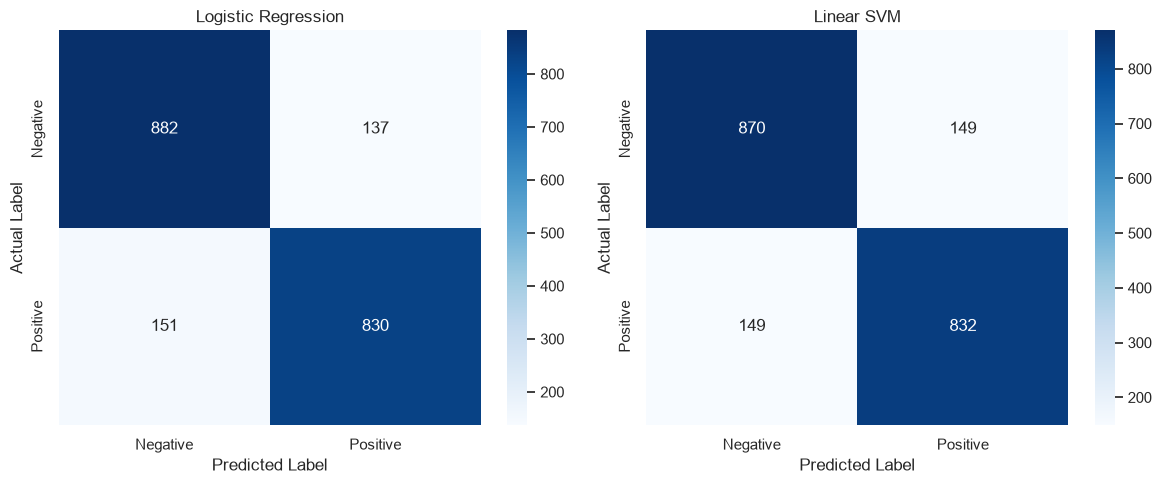

In [46]:
# Confusion Matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression confusion matrix
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=axes[0]
)

axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")


# Linear SVM confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=axes[1]
)

axes[1].set_title("Linear SVM")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    make_scorer
)

In [48]:
f1_scorer = make_scorer(
    f1_score,
    pos_label="pos"
)

In [49]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [50]:
# Logistic Regression - 5 Fold Cross-Validation

logistic_cv_scores = cross_val_score(
    LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    X_train_tfidf,
    y_train,
    cv=cv,
    scoring=f1_scorer
)

print("Logistic Regression - 5 Fold F1 Scores:")
print(logistic_cv_scores)

print("\nLogistic Regression Mean F1:",
      logistic_cv_scores.mean())

print("Logistic Regression F1 Standard Deviation:",
      logistic_cv_scores.std())

Logistic Regression - 5 Fold F1 Scores:
[0.84269663 0.85057471 0.86363636 0.86080821 0.87300574]

Logistic Regression Mean F1: 0.858144331868728
Logistic Regression F1 Standard Deviation: 0.01052664114242896


In [51]:
# Linear SVM - 5 Fold Cross-Validation

svm_cv_scores = cross_val_score(
    LinearSVC(random_state=42),
    X_train_tfidf,
    y_train,
    cv=cv,
    scoring=f1_scorer
)

print("Linear SVM - 5 Fold F1 Scores:")
print(svm_cv_scores)

print("\nLinear SVM Mean F1:",
      svm_cv_scores.mean())

print("Linear SVM F1 Standard Deviation:",
      svm_cv_scores.std())

Linear SVM - 5 Fold F1 Scores:
[0.83979975 0.85098288 0.85840708 0.85070785 0.86551944]

Linear SVM Mean F1: 0.853083399611628
Linear SVM F1 Standard Deviation: 0.008596597272521204


In [52]:
# Final Model Comparison

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM"],
    "Accuracy": [logistic_accuracy, svm_accuracy],
    "Precision": [logistic_precision, svm_precision],
    "Recall": [logistic_recall, svm_recall],
    "F1-Score": [logistic_f1, svm_f1],
    "CV Mean F1": [
        logistic_cv_scores.mean(),
        svm_cv_scores.mean()
    ],
    "CV Std F1": [
        logistic_cv_scores.std(),
        svm_cv_scores.std()
    ]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,CV Mean F1,CV Std F1
0,Logistic Regression,0.856,0.8583,0.8461,0.8522,0.8581,0.0105
1,Linear SVM,0.851,0.8481,0.8481,0.8481,0.8531,0.0086


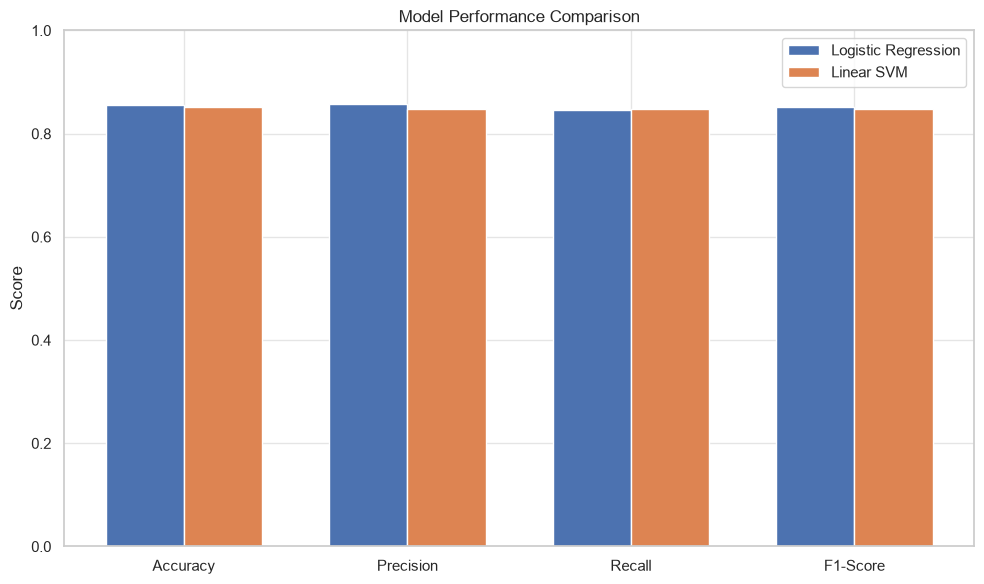

In [53]:
# Compare Model Performance

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    comparison.loc[0, metrics],
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width / 2,
    comparison.loc[1, metrics],
    width,
    label="Linear SVM"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.legend()

plt.tight_layout()
plt.show()

# Conclusion

This project developed an automated Natural Language Processing system for classifying Amazon customer reviews as Positive or Negative.

## Key Findings

- The dataset contained **10,000 customer reviews** with two columns: `label` and `review`.
- There were **no missing values** and **no duplicate rows** after data cleaning.
- Text preprocessing included:
  - Lowercasing
  - HTML tag removal
  - URL removal
  - Contraction handling
  - Punctuation removal
  - Stopword removal
  - Removal of very short words
- Exploratory analysis showed that the dataset contained **4,903 positive reviews** and **5,097 negative reviews**.
- Word-frequency analysis and word clouds provided insights into commonly used terms in positive and negative reviews.
- TF-IDF with unigrams and bigrams was used to convert text into **20,000 numerical features**.
- Two classification models were evaluated:
  - Logistic Regression
  - Linear SVM

## Model Performance

Logistic Regression achieved:

- Accuracy: **85.60%**
- Precision: **85.83%**
- Recall: **84.61%**
- F1-score: **85.22%**

Linear SVM achieved:

- Accuracy: **85.10%**
- Precision: **84.81%**
- Recall: **84.81%**
- F1-score: **84.81%**

The 5-fold cross-validation results were:

- Logistic Regression Mean F1-score: **0.8581**
- Linear SVM Mean F1-score: **0.8531**

## Final Model Selection

Based on the test-set performance and cross-validation results, **Logistic Regression was selected as the final model** because it achieved the highest overall accuracy and F1-score.

The results demonstrate that TF-IDF combined with traditional machine learning models can effectively classify customer reviews and provide useful insights into customer sentiment.

## Business Insights

An automated sentiment analysis system can help an e-commerce company:

- Monitor customer satisfaction.
- Identify negative customer feedback quickly.
- Detect potential product-related problems.
- Understand common themes in customer reviews.
- Support faster responses to customer complaints.